In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/khngtrnnht/dataset/online_retail_II.xlsx


In [2]:
print(pd.ExcelFile('/kaggle/input/datasets/khngtrnnht/dataset/online_retail_II.xlsx').sheet_names)

['Year 2009-2010', 'Year 2010-2011']


1. Review Data

In [3]:
import pandas as pd

df1 = pd.read_excel('/kaggle/input/datasets/khngtrnnht/dataset/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('/kaggle/input/datasets/khngtrnnht/dataset/online_retail_II.xlsx', sheet_name='Year 2010-2011')


In [4]:
type(df1), type(df2)

(pandas.core.frame.DataFrame, pandas.core.frame.DataFrame)

In [5]:
df = pd.concat([df1,df2], ignore_index=True)

In [6]:
print(df.shape)

(1067371, 8)


In [7]:
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [8]:
df.dropna(inplace=True)

In [9]:
print(df.isnull().sum())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [10]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,824364.000000,824364,824364.000000,824364.000000
mean,12.414574,2011-01-01 22:29:28.042054144,3.676800,15324.638504
min,-80995.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-07-06 11:58:00,1.250000,13975.000000
50%,5.000000,2010-12-03 14:26:00,1.950000,15255.000000
75%,12.000000,2011-07-27 15:14:00,3.750000,16797.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,188.976099,NaN,70.241388,1697.464450


In [11]:
len(df[df['Quantity']<0])

18744

In [12]:
len(df[df['Price']<=0])

71

In [13]:
len(df[df['Invoice'].str.startswith('C', na=False)])

18744

In [14]:
df = df[df['Quantity'] > 0]

In [15]:
df = df[df['Price'] > 0]

In [16]:
len(df[df['Quantity']<0])

0

In [17]:
len(df[df['Price']<0])

0

In [18]:
df['TotalPrice'] = df['Quantity'] * df['Price']

In [19]:
df.shape

(805549, 9)

In [20]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,59.5
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.6
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom,45.0


In [21]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [22]:
df['InvoiceDate'].min(), df['InvoiceDate'].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2011-12-09 12:50:00'))

In [23]:
snapshot_date = df['InvoiceDate'].max() + pd.offsets.MonthEnd(0)

In [24]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [25]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,222.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,22.000000,1.000000,2.950000
25%,47.000000,1.000000,348.762500
50%,117.000000,3.000000,898.915000
75%,401.000000,7.000000,2307.090000
max,760.000000,398.000000,608821.650000


In [26]:
rfm.sort_values('Monetary', ascending=False).head(10)

,Recency,Frequency,Monetary
Customer ID,,,
18102.0,22,145,608821.65
14646.0,23,151,528602.52
14156.0,31,156,313946.37
14911.0,22,398,295972.63
17450.0,29,51,246973.09
13694.0,25,143,196482.81
17511.0,24,60,175603.55
16446.0,22,2,168472.50
16684.0,25,55,147142.77


In [27]:
Q1 = rfm['Monetary'].quantile(0.25)

In [28]:
Q3 = rfm['Monetary'].quantile(0.75)

In [29]:
IQR = Q3 - Q1

In [30]:
upper_bound = Q3 + 1.5 * IQR

In [31]:
rfm_vip = rfm[rfm['Monetary'] > upper_bound]

In [32]:
rfm_normal = rfm[rfm['Monetary'] <= upper_bound]

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(rfm_normal[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = pd.DataFrame(scaled_data, columns=['Recency', 'Frequency', 'Monetary'], index=rfm_normal.index)

In [33]:
rfm_vip.shape

(628, 3)

In [34]:
rfm_normal.shape

(5250, 3)

In [36]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,5.250000e+03,5.250000e+03,5.250000e+03
mean,8.721066e-17,1.353415e-17,4.330927e-17
std,1.000095e+00,1.000095e+00,1.000095e+00
min,-1.030238e+00,-7.418054e-01,-9.953145e-01
25%,-8.790455e-01,-7.418054e-01,-7.303783e-01
50%,-4.065676e-01,-2.344146e-01,-3.726638e-01
75%,8.218748e-01,2.729763e-01,3.923223e-01
max,2.456648e+00,2.437404e+01,3.435364e+00


In [37]:
rfm_scaled.head(10)

,Recency,Frequency,Monetary
Customer ID,,,
12348.0,-0.680605,0.272976,0.712735
12349.0,-0.945192,0.019281,2.753542
12350.0,0.429718,-0.741805,-0.714557
12351.0,0.736829,-0.741805,-0.742908
12352.0,-0.864871,1.541453,1.416165
12353.0,-0.071108,-0.488110,-0.653264
12354.0,0.061185,-0.741805,-0.083499
12355.0,-0.023861,-0.488110,-0.195133
12358.0,-1.025514,0.272976,2.294758


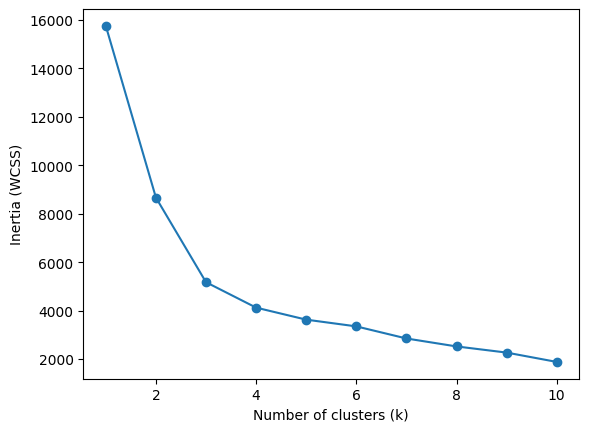

In [38]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.show()

In [41]:
kmeans = KMeans(n_clusters=3, random_state=42)
rfm_normal['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm_normal.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(cluster_summary), print(rfm_normal['Cluster'].value_counts())

            Recency  Frequency     Monetary
Cluster                                    
0         91.001022   9.915133  3205.519084
1        495.114880   1.850109   530.665242
2        108.917349   3.077741   850.785607
Cluster
2    2444
1    1828
0     978
Name: count, dtype: int64


/tmp/ipykernel_58/1055385136.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_normal['Cluster'] = kmeans.fit_predict(rfm_scaled)


(None, None)

In [44]:
rfm_normal['Segment'] = rfm_normal['Cluster'].map({0: 'Champions', 1: 'Churned', 2: 'Potential'})

/tmp/ipykernel_58/856617129.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_normal['Segment'] = rfm_normal['Cluster'].map({0: 'Champions', 1: 'Churned', 2: 'Potential'})


In [46]:
rfm_normal.head(10)

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12348.0,96,5,2019.40,2,Potential
12349.0,40,4,4428.69,0,Champions
12350.0,331,1,334.40,1,Churned
12351.0,396,1,300.93,1,Churned
12352.0,57,10,2849.84,0,Champions
12353.0,225,2,406.76,2,Potential
12354.0,253,1,1079.40,2,Potential
12355.0,235,2,947.61,2,Potential
12358.0,23,5,3887.07,0,Champions


In [48]:
rfm_normal['Segment'].value_counts()

Segment
Potential    2444
Churned      1828
Champions     978
Name: count, dtype: int64

In [49]:
rfm_vip['Segment'] = 'VIP'

/tmp/ipykernel_58/1220041521.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_vip['Segment'] = 'VIP'


In [50]:
rfm_vip.head()

,Recency,Frequency,Monetary,Segment
Customer ID,,,,
12346.0,347,12,77556.46,VIP
12347.0,23,8,5633.32,VIP
12356.0,44,6,6373.68,VIP
12357.0,54,3,18287.66,VIP
12359.0,79,10,8935.94,VIP


In [51]:
rfm_final = pd.concat([rfm_normal, rfm_vip])

In [52]:
rfm_final.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12348.0,96,5,2019.40,2.0,Potential
12349.0,40,4,4428.69,0.0,Champions
12350.0,331,1,334.40,1.0,Churned
12351.0,396,1,300.93,1.0,Churned
12352.0,57,10,2849.84,0.0,Champions


In [58]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [54]:
rfm_final.shape

(5878, 5)

In [55]:
rfm_final.index.is_unique

True

In [56]:
rfm_final.to_csv('rfm_final.csv')

In [57]:
df.to_csv('data_final.csv')